<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/17_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Machine Learning
### Session 17.1 | Applied Machine Learning

Welcome to Module 5! Over the next few sessions, you'll go from "what is ML?"
to building full preprocessing-to-deployment pipelines. This first session
lays the conceptual foundation everything else builds on.

**By the end of this notebook, you will be able to:**
- Distinguish supervised, unsupervised, and other learning paradigms
- Describe every stage of the ML lifecycle and why each one matters
- Tell regression and classification problems apart at a glance
- Write your first scikit-learn `fit → predict → score` workflow

## Why do we need Machine Learning at all?

Imagine you want to predict house prices. A traditional (rule-based)
program requires *you* to write the rules:

if bedrooms > 3 and location == "downtown":
price = 500000
elif ...

This breaks down almost immediately — there are too many variables,
too many interactions, and the rules keep changing.

**Machine Learning flips the approach.** Instead of hand-coding rules,
we show the algorithm many examples of inputs (house features) and
outputs (actual sale prices), and let it *learn the rule itself*.

| Traditional Programming | Machine Learning |
|---|---|
| Rules + Data → Output | Data + Output → Rules (Model) |
| You write the logic | The algorithm infers the logic |
| Brittle to new patterns | Generalizes to unseen patterns |
| Deterministic | Probabilistic / statistical |

This is Arthur Samuel's classic 1959 definition: ML gives computers
**"the ability to learn without being explicitly programmed."**

### What is Machine Learning?

Machine learning (ML) is a subfield of artificial intelligence (AI) that enables systems to learn from data, identify patterns, and make decisions or predictions with minimal human intervention. Instead of being explicitly programmed with rules for every possible scenario, ML algorithms build a mathematical model based on sample data, known as "training data," in order to make predictions or decisions without being explicitly programmed to perform the task.

Key characteristics of Machine Learning:

*   **Learning from Data:** ML algorithms are trained on large datasets, extracting insights and relationships.
*   **Pattern Recognition:** They excel at identifying complex patterns that might be difficult for humans to discern.
*   **Generalization:** A good ML model can generalize from the training data to make accurate predictions on new, unseen data.
*   **Adaptation:** As more data becomes available, ML models can be retrained and improved, allowing them to adapt to changing environments or new information.

Machine learning is broadly categorized into several paradigms, including supervised learning, unsupervised learning, and reinforcement learning, each suited for different types of problems and data.

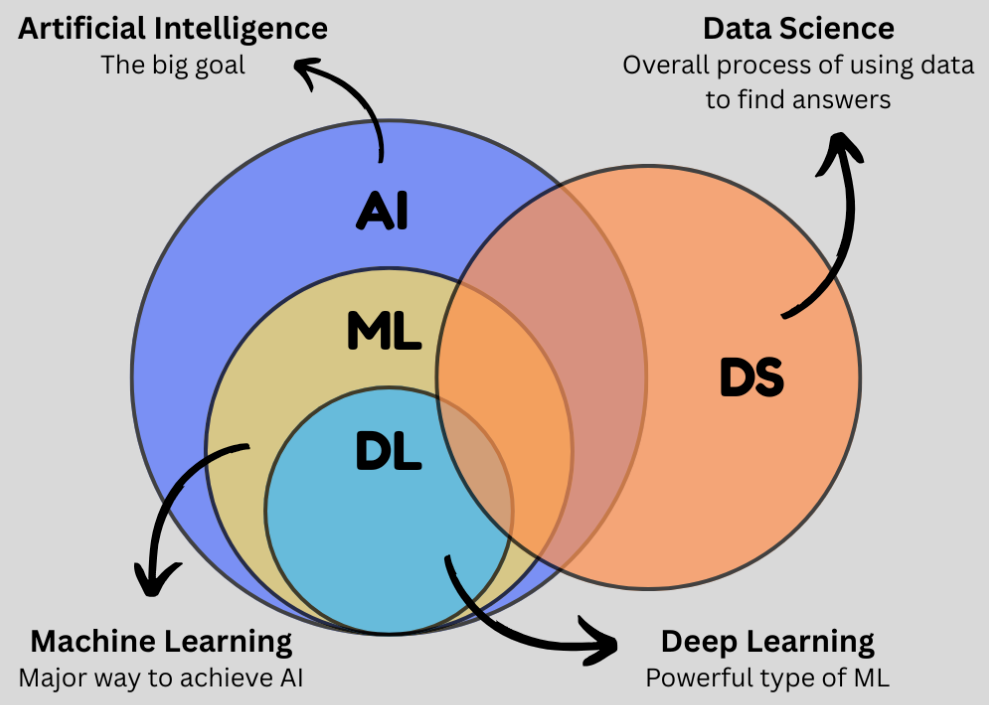

These terms are often used interchangeably, but they represent different levels of abstraction within the field of artificial intelligence.

*   **Artificial Intelligence (AI):** The broadest concept, encompassing any technique that enables computers to mimic human intelligence. This includes systems that can solve problems, learn, reason, perceive, and understand language. Examples include playing chess, talking to voice assistants like Alexa, or self-driving cars.

*   **Machine Learning (ML):** A subset of AI that allows systems to learn from data without being explicitly programmed. ML algorithms build models from data to make predictions or decisions. Examples include Netflix predicting the next movie you'll watch or Spotify giving music suggestions.

*   **Deep Learning (DL):** A subfield of Machine Learning that uses neural networks with many layers (deep neural networks), inspired by the structure and function of the human brain. Deep learning excels at tasks involving large amounts of data, such as image recognition, natural language processing, and speech recognition. Examples include facial recognition on phones or large language models like ChatGPT.

## 1. The Learning Paradigms

Machine Learning problems are usually grouped by **how much guidance
(labels) the algorithm gets** during training.

### Supervised Learning
The algorithm learns from **labeled data** — every training example has
a known "correct answer" (target/label). The goal is to learn a mapping
`f(X) → y` that generalizes to new, unseen inputs.

- Analogy: learning with a teacher who grades your answers.
- Requires labeled data (often the expensive/hard part in practice).
- Two main flavors: **Regression** (continuous output) and
  **Classification** (categorical output) — covered in detail below.
- Examples: spam detection, credit default prediction, house price
  prediction, medical diagnosis from lab results.

### Unsupervised Learning
The algorithm learns from **unlabeled data** — there is no "correct
answer" provided. The goal is to discover hidden structure, patterns,
or groupings in the data itself.

- Analogy: being handed a pile of documents and asked to organize them
  with no instructions on categories.
- No labels needed — often used when labeling is expensive or the goal
  is exploratory.
- Main tasks: **Clustering** (grouping similar points), **Dimensionality
  Reduction** (compressing features), **Association** (finding
  co-occurring items, e.g. market basket analysis).
- Examples: customer segmentation, anomaly detection, topic modeling,
  compressing image data before feeding it to another model.

### Other paradigms worth knowing (breadth, not depth, for now)
| Paradigm | One-line description | Where it's used |
|---|---|---|
| Semi-supervised | Small labeled set + large unlabeled set | Medical imaging (few labeled scans) |
| Self-supervised | Labels generated automatically from the data itself | Pretraining LLMs, embeddings |
| Reinforcement Learning | Agent learns via reward/penalty from an environment | Robotics, game-playing, recommendation systems |

We will focus almost entirely on **supervised learning** in Weeks 17–18,
then cover **unsupervised learning** (K-Means, PCA) in Week 19.

### Quick comparison table

| Aspect | Supervised | Unsupervised |
|---|---|---|
| Input data | Labeled (X, y) | Unlabeled (X only) |
| Goal | Predict a known target | Discover hidden structure |
| Feedback signal | Error vs. true label | No explicit feedback |
| Evaluation | Straightforward (compare prediction vs. truth) | Harder — often qualitative or indirect |
| Example algorithms | Linear/Logistic Regression, Decision Trees, Random Forest | K-Means, PCA, Hierarchical Clustering |

In [1]:
# Core libraries for this session
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn — the library we'll use throughout this module
import sklearn
from sklearn.datasets import fetch_california_housing, load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("scikit-learn version:", sklearn.__version__)
print("pandas version:", pd.__version__)

scikit-learn version: 1.6.1
pandas version: 2.2.2


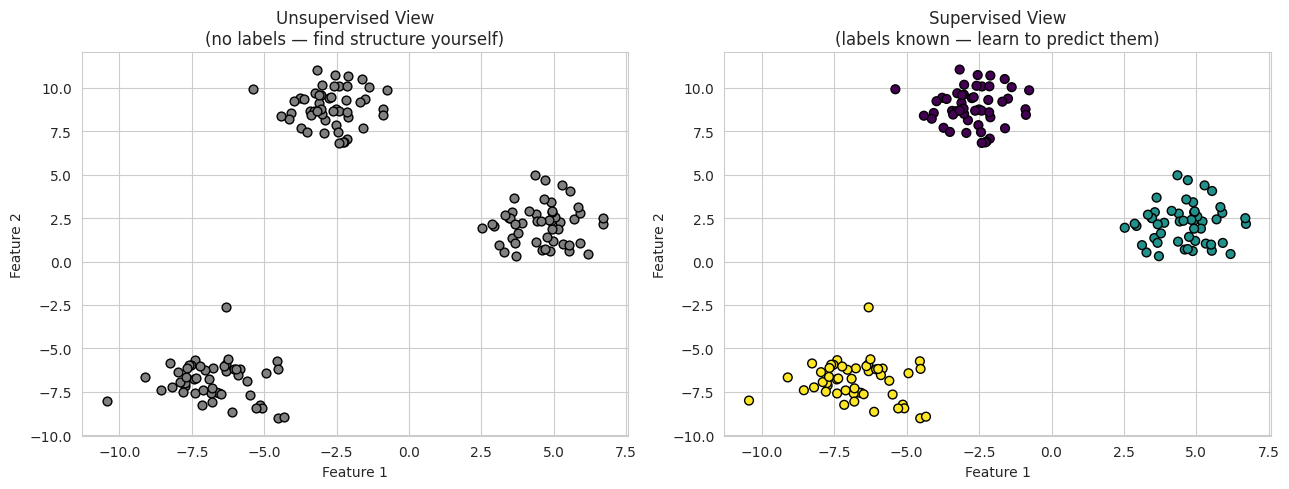

In [2]:
# Generate a small synthetic dataset to *see* the difference visually
from sklearn.datasets import make_blobs

X, y_true = make_blobs(n_samples=150, centers=3, cluster_std=1.1, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT: what UNSUPERVISED learning sees — no labels/colors, just points
axes[0].scatter(X[:, 0], X[:, 1], c="gray", s=40, edgecolor="k")
axes[0].set_title("Unsupervised View\n(no labels — find structure yourself)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# RIGHT: what SUPERVISED learning sees — labels are known (colors = classes)
scatter = axes[1].scatter(X[:, 0], X[:, 1], c=y_true, cmap="viridis", s=40, edgecolor="k")
axes[1].set_title("Supervised View\n(labels known — learn to predict them)")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

if I gave you only the left plot, could you still guess there might be 3 groups?

## 2. The Machine Learning Lifecycle

A model is never "just trained" — in the real world it moves through a
repeatable cycle. This maps closely to the industry-standard **CRISP-DM**
framework (Cross-Industry Standard Process for Data Mining), which you'll
see referenced in production ML teams.

### The 8 Stages

1. **Business/Problem Understanding**
   Define the actual question. "Predict churn" is vague — "predict which
   customers will cancel their subscription in the next 30 days, so the
   retention team can intervene" is a problem you can build for.

2. **Data Collection**
   Gather data from databases, APIs, logs, sensors, third-party sources.
   Quality and relevance matter more than volume at this stage.

3. **Data Cleaning & Exploratory Data Analysis (EDA)**
   Handle missing values, duplicates, outliers, inconsistent formats.
   Visualize distributions and relationships to build intuition — this
   is often 60–80% of real-world project time.

4. **Feature Engineering & Selection**
   Transform raw data into inputs the model can learn from (encoding,
   scaling, creating new features).

5. **Model Selection & Training**
   Choose an appropriate algorithm family (this course covers Linear/
   Logistic Regression, Trees, Ensembles, KNN) and fit it to training
   data.

6. **Evaluation**
   Measure performance on **unseen** data using appropriate metrics
   (MSE/R² for regression; Accuracy/Precision/Recall/F1/ROC-AUC for
   classification ).

7. **Hyperparameter Tuning & Validation**
   Systematically search for the best model configuration using
   cross-validation, avoiding overfitting to a single train/test split.

8. **Deployment & Monitoring**
   Ship the model into a real system, then continuously monitor for
   **data drift** and **model decay** — since real-world data changes
   over time, models need retraining. This closes the loop, making the
   lifecycle circular, not linear.

## 3. Regression vs Classification

Both are **supervised learning** tasks — the difference is the *type of
target variable (`y`)* you're trying to predict.

### Regression
Predicts a **continuous, numeric quantity**.
- "How much?" or "How many?"
- Output can (in principle) take any value in a range.
- Examples: house price ($245,300), temperature (28.6°C), stock price,
  a student's exam score, delivery time in minutes.
- Session 17.2 (next!) covers this in depth via Linear Regression.

### Classification
Predicts a **discrete category / class label**.
- "Which one?" or "Yes or no?"
- Output is one of a fixed, finite set of classes.
- **Binary classification**: 2 classes (spam/not-spam, churn/no-churn,
  malignant/benign).
- **Multiclass classification**: 3+ classes (species of iris, digit
  0–9, sentiment: positive/neutral/negative).
- Session 17.3 covers Logistic Regression, the standard starting point.

### Key Differences

The fundamental difference between regression and classification lies in the nature of the target variable (the `y` you are trying to predict):

*   **Regression**:
    *   **Goal:** Predict a **continuous, numerical value**.
    *   **Output:** A number that can fall anywhere within a range (e.g., house price, temperature, sales figures, age).
    *   **Questions it answers:** "How much?" or "How many?"
    *   **Examples:** Predicting the exact price of a house, forecasting stock prices, estimating a person's age based on their photo.

*   **Classification**:
    *   **Goal:** Predict a **discrete category or class label**.
    *   **Output:** One of a finite set of predefined categories (e.g., spam/not spam, cat/dog, positive/negative sentiment, types of diseases).
    *   **Questions it answers:** "Which one?" or "Is this A or B?"
    *   **Examples:** Detecting if an email is spam, identifying the type of animal in an image, classifying a customer as a churn risk or not.

In essence, if you're predicting a quantity, it's typically regression. If you're predicting a choice or a group, it's classification.

### How to tell which one you need
Ask: **"Is my target variable a number I could average, or a label I
could count?"**

| Question | Target variable | Task type |
|---|---|---|
| What will this house sell for? | Price ($) | Regression |
| Will this customer churn? | Yes / No | Classification (binary) |
| How many units will we sell next month? | Units (count) | Regression |
| What handwritten digit is this? | 0–9 | Classification (multiclass) |
| What's this patient's blood pressure? | mmHg (number) | Regression |
| Is this transaction fraudulent? | Fraud / Not fraud | Classification (binary) |

> **Common trap:** A target that *looks* numeric isn't always
> regression. "Star rating 1–5" is technically discrete and ordered —
> it can be modeled as regression, multiclass classification, or with
> specialized **ordinal regression** methods depending on the goal.
> Always think about what the number *means*, not just its data type.

## 4. Scikit-learn: The Toolkit We'll Use All Course

Scikit-learn is the standard Python library for classical ML. Its
biggest strength is a **consistent API** — once you learn the pattern,
it works the same way across dozens of algorithms.

### The Core Pattern: `fit → predict → score`

Every scikit-learn model (called an **estimator**) follows this contract:

| Method | Purpose |
|---|---|
| `.fit(X, y)` | Learn parameters from training data |
| `.predict(X)` | Generate predictions on new data |
| `.score(X, y)` | Quick built-in performance metric |
| `.transform(X)` | (Transformers only) apply a learned transformation, e.g. scaling |
| `.fit_transform(X)` | Fit and transform in one step (common for preprocessing) |

### Data conventions
Scikit-learn expects data in a specific shape:
- **`X`** — feature matrix, shape `(n_samples, n_features)`. Even a
  single feature must be 2D: `(n_samples, 1)`.
- **`y`** — target vector, shape `(n_samples,)`.

### The Scikit-Learn Workflow: Initialize, Fit, Predict

]In Python, the industry standard tool for Machine Learning is a library called `scikit-learn`.

The most beautiful thing about scikit-learn is its consistency. Whether you are building a simple linear model to predict house prices today, or a massive neural network to classify images next month, the workflow remains exactly the same. It all comes down to three intuitive steps:

1. **Initialize:** You pick your mathematical tool and set it up.
2. **Fit:** You give the tool historical data so it can learn the hidden patterns.
3. **Predict:** You ask the trained tool to make guesses on brand new data it has never seen before.

Let us look at a tiny, simulated example to understand this workflow before we touch any complex datasets.

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
# Let's imagine we have three students.
# X represents the hours they studied (our feature). Scikit-learn expects a 2D list for features.
X_study_hours = [[1], [2], [3]]

In [ ]:
# y represents the score they got on their exam (our target output).
y_exam_scores = [10, 20, 30]

In [ ]:
# Step 1: Initialize our tool. We are telling Python we want to draw a straight line through our data.
simple_model = LinearRegression()

In [ ]:
# Step 2: Fit the model. This is where the actual "learning" happens.
# We are handing the model the study hours and the scores, and asking it to find the relationship.
simple_model.fit(X_study_hours, y_exam_scores)

LinearRegression()

In [ ]:
# Step 3: Predict! A new student comes in and says they studied for 4 hours.
# We ask our trained model what score they will likely get.
new_student = [[4]]
predicted_score = simple_model.predict(new_student)

In [ ]:
print(f"If a student studies for 4 hours, the model predicts a score of: {predicted_score[0]}")

# Notice how intuitive that was? We didn't write any if/else statements.
# The model learned that 1 hour equals 10 points entirely on its own.

If a student studies for 4 hours, the model predicts a score of: 39.99999999999999


### Applying Our Workflow to Real Data: The California Housing Dataset

Now that we understand the basic three-step workflow (Initialize, Fit, Predict), let us apply it to a real-world problem. We are going to use the California Housing Dataset.

A quick note on this data: each row you are about to see does not represent a single house. Instead, it represents a specific block group or neighborhood in California. Our ultimate goal for this session is to see if we can predict the median house value of a neighborhood based on features like the median income of its residents, the average age of the houses, and the number of rooms. Let us load it in and take a look.

This dataset contains information from the 1990 California census. Each row represents a block group, which is the smallest geographical unit for which the U.S. Census Bureau publishes sample data (a block group typically has a population of 600 to 3000 people).

The target variable `MedHouseVal` (Median House Value) is the median house value for California districts, expressed in hundreds of thousands of dollars ($100,000s).

Key features include:
- `MedInc`: Median income in block group (in $10,000s)
- `HouseAge`: Median house age in block group
- `AveRooms`: Average number of rooms per household
- `AveBedrms`: Average number of bedrooms per household
- `Population`: Block group population
- `AveOccup`: Average household occupancy
- `Latitude`: Block group latitude
- `Longitude`: Block group longitude

In [ ]:
# We use scikit-learn's reliable built-in dataset loader
from sklearn.datasets import fetch_california_housing

In [ ]:
# Fetch the data directly from the library
california = fetch_california_housing()

In [ ]:
# Convert it into a Pandas DataFrame so it is easier for us to read and manipulate
df = pd.DataFrame(california.data, columns=california.feature_names)

In [ ]:
# Add our target variable (the house prices we want to predict) to the dataset
# Note: The target values are expressed in hundreds of thousands of dollars ($100,000)
df['MedHouseVal'] = california.target

In [ ]:
# Let's take a look at the first 5 rows to understand our starting point
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### The Golden Rule of Machine Learning: The Train-Test Split

Before we hand our data over to scikit-learn, we must address a critical concept. Think about how you study for an exam. If a professor gives you a practice quiz, you use it to learn. But if the professor gives you the *exact same* practice questions on the final exam, getting a perfect score does not prove you understand the subject—it just proves you memorized the answers.

In Machine Learning, we call this memorization "overfitting." If we train our model on our entire dataset and then test its accuracy on that same data, our model will look artificially perfect.

To truly know if our model is smart, we must follow a strict rule: **Never evaluate your model on the same data it used for learning.** We achieve this by splitting our data into two separate piles: a Training Set (usually 80%) for the model to learn from, and a Testing Set (20%) that we lock away in a vault to test the model with later.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# First, we separate our features (the neighborhood stats) from our target (the house values)
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

In [ ]:
# Now we split the data. We keep 80% for training, and lock 20% away for testing.
# The random_state ensures that everyone in class gets the exact same random split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Total neighborhoods in dataset: {len(df)}")
print(f"↳ Neighborhoods assigned for learning (Training): {len(X_train)}")
print(f"↳ Neighborhoods reserved for evaluation (Testing): {len(X_test)}\n")

Total neighborhoods in dataset: 20640
↳ Neighborhoods assigned for learning (Training): 16512
↳ Neighborhoods reserved for evaluation (Testing): 4128



### Training the Real-World Model

It is time to run our exact same 3-step scikit-learn workflow on this real-world data. We will initialize our Linear Regression tool, fit it using *only* the training data, and then ask it to predict the prices for the test data.

In [ ]:
from sklearn.linear_model import LinearRegression

# Step 1: INITIALIZE the model
real_world_model = LinearRegression()

In [ ]:
# Step 2: FIT the model
# We let the model learn the relationship between neighborhood stats and house prices.
# Notice we are ONLY giving it the training data. No peeking at the test data allowed.
real_world_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Step 3: PREDICT
# We bring out our hidden test data and ask the model to guess the house values.
test_predictions = real_world_model.predict(X_test)

In [ ]:
# Let's inspect the first 5 predictions side-by-side with the actual target values
for i in range(5):
    actual = y_test.iloc[i] * 100000  # Multiplying by 100k to show actual dollar amounts
    predicted = test_predictions[i] * 100000
    difference = abs(actual - predicted)

    print(f"Block {i+1}: Model Guessed: ${predicted:,.0f} | Real Value: ${actual:,.0f} (Off by: ${difference:,.0f})")

Block 1: Model Guessed: $71,912 | Real Value: $47,700 (Off by: $24,212)
Block 2: Model Guessed: $176,402 | Real Value: $45,800 (Off by: $130,602)
Block 3: Model Guessed: $270,966 | Real Value: $500,001 (Off by: $229,035)
Block 4: Model Guessed: $283,893 | Real Value: $218,600 (Off by: $65,293)
Block 5: Model Guessed: $260,466 | Real Value: $278,000 (Off by: $17,534)


### Did it work? Visualizing the Results

Looking at a few printed text numbers is nice, but it does not give us the full picture of how our model performed across all 4,128 test neighborhoods. In machine learning, visualizing our errors is incredibly important.

Let us plot our model's predictions against the actual real-world prices. If our model was absolutely perfect, every single dot would fall exactly on a perfectly straight diagonal line. The further the dots scatter away from that line, the bigger our model's errors are.

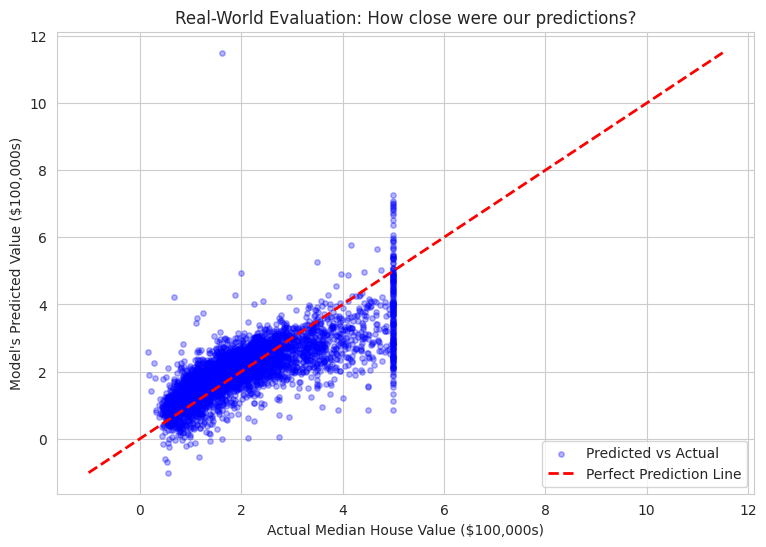

In [ ]:
# Create a scatter plot comparing actual values vs predicted values
plt.figure(figsize=(9, 6))
plt.scatter(y_test, test_predictions, alpha=0.3, color='blue', s=15, label='Predicted vs Actual')

# Draw the "Perfect Prediction" diagonal line for reference
# If a prediction is perfect, predicted value = actual value
max_val = max(y_test.max(), test_predictions.max())
min_val = min(y_test.min(), test_predictions.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.xlabel("Actual Median House Value ($100,000s)")
plt.ylabel("Model's Predicted Value ($100,000s)")
plt.title("Real-World Evaluation: How close were our predictions?")
plt.legend()
plt.show()

# As we can see, the model captures the general upward trend, but it's far from perfect.
# In the next session, we will learn the mathematical metrics (like MSE and R-squared)
# to put a concrete score on exactly how well this line fits!

### 4. Predicting Categories (Classification)

Linear regression is fantastic when we want to predict a continuous number, like a house price. But what if our problem is not a number? What if we want to predict a category?
* Is an email *Spam* or *Not Spam*?
* Is a bank transaction *Fraudulent* or *Legitimate*?

This is a totally different branch of Machine Learning called **Classification**.

To solve this, we are going to use a model called **Logistic Regression**. Do not let the name fool you—despite having "regression" in its name for historical mathematical reasons, it is actually a classifier used to predict categories.

Let us load a classic real-world dataset to see this in action: The Breast Cancer Wisconsin dataset. We are going to ask our model to look at the physical measurements of cells and classify whether a tumor is Malignant (dangerous) or Benign (safe).

This dataset is a classic and widely used resource in machine learning, particularly for classification tasks. It contains features computed from digitized images of a fine needle aspirate (FNA) of a breast mass. These features describe characteristics of the cell nuclei present in the image.

The target variable `Diagnosis` indicates whether the tumor is Malignant (0) or Benign (1).

Key features (30 in total) include:
- `radius`: mean of distances from center to points on the perimeter
- `texture`: standard deviation of gray-scale values
- `perimeter`: perimeter of the tumor
- `area`: area of the tumor
- `smoothness`: local variation in radius lengths
- `compactness`: perimeter^2 / area - 1.0
- `concavity`: severity of concave portions of the contour
- `concave points`: number of concave portions of the contour
- `symmetry`: symmetry of the tumor
- `fractal_dimension`: "coastline approximation" - 1

Each of these 10 features is calculated for the mean, standard error, and "worst" (mean of the three largest values) for each image, resulting in 30 features.

In [ ]:
from sklearn.datasets import load_breast_cancer

In [ ]:
# Fetch the dataset
cancer_data = load_breast_cancer()

In [ ]:
# Convert to Pandas DataFrame
df_cancer = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

In [ ]:
# Add our target variable.
# Notice this isn't a dollar amount. It is simply a 0 (Malignant) or a 1 (Benign).
df_cancer['Diagnosis'] = cancer_data.target

In [ ]:
# Let's peek at the cellular features we have available to learn from
display(df_cancer.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### The Magic of Scikit-Learn: The Same 3 Steps

Here is where the magic of the scikit-learn framework becomes clear. Even though we are solving a completely different type of problem (Classification instead of Regression) with a completely different mathematical engine, the code workflow is virtually identical.

We will follow our Golden Rule by splitting the data, and then we will Initialize, Fit, and Predict.

In [ ]:
from sklearn.linear_model import LogisticRegression
# Note: We already imported train_test_split earlier, so we can just use it!

In [ ]:
# Step 1: Separate features (cell measurements) and target (diagnosis)
X_class = df_cancer.drop(columns=['Diagnosis'])
y_class = df_cancer['Diagnosis']

In [ ]:
# Step 2: The Golden Rule (80/20 Train-Test Split)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

In [ ]:
print(f"Training on {len(X_train_c)} patients, keeping {len(X_test_c)} hidden for testing.\n")

Training on 455 patients, keeping 114 hidden for testing.



In [ ]:
# --- The 3-Step Workflow ---

# 1. INITIALIZE
# We increase 'max_iter' simply because real-world medical data takes a bit more time for the math to settle
classifier_model = LogisticRegression(max_iter=10000)

In [ ]:
# 2. FIT (Learn the difference between benign and malignant cells)
classifier_model.fit(X_train_c, y_train_c)

LogisticRegression(max_iter=10000)

In [ ]:
# 3. PREDICT (Guess the diagnosis for our hidden test patients)
class_predictions = classifier_model.predict(X_test_c)

### Did it work? Evaluating a Classifier

With our house prices, we checked how many dollars our predictions were off by. With classification, it is much simpler: we are either right, or we are wrong.

Instead of a scatter plot, our primary metric here is **Accuracy**. Out of the 114 test patients we hid in our vault, what percentage did the model diagnose perfectly? Let us calculate the score and check a few individual patients.

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
# Calculate total accuracy (Correct Predictions / Total Predictions)
accuracy = accuracy_score(y_test_c, class_predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

Model Accuracy: 95.61%



In [ ]:
# Let's look at the first 5 individual patients in our test set to see the results
# The dataset stores the text names for 0 and 1 in 'target_names'
names = cancer_data.target_names

In [ ]:
names

array(['malignant', 'benign'], dtype='<U9')

In [ ]:
for i in range(5):
    # Get the actual and predicted values and translate them from 0/1 to Text
    actual_diagnosis = names[y_test_c.iloc[i]]
    predicted_diagnosis = names[class_predictions[i]]

    # Simple check to see if we got it right
    if actual_diagnosis == predicted_diagnosis:
        status = "CORRECT"
    else:
        status = "INCORRECT"

    print(f"Patient {i+1}: Model guessed '{predicted_diagnosis}' | Actual was '{actual_diagnosis}' -> {status}")

Patient 1: Model guessed 'benign' | Actual was 'benign' -> CORRECT
Patient 2: Model guessed 'malignant' | Actual was 'malignant' -> CORRECT
Patient 3: Model guessed 'malignant' | Actual was 'malignant' -> CORRECT
Patient 4: Model guessed 'benign' | Actual was 'benign' -> CORRECT
Patient 5: Model guessed 'benign' | Actual was 'benign' -> CORRECT


## Mistakes to Avoid From Day One

These mistakes are common enough — including among working engineers —
that it's worth internalizing them now, before bad habits form.

1. **Evaluating on training data.** A model's score on the data it
   learned from tells you almost nothing about real-world performance.
   Always hold out a test set (or use cross-validation, Week 20).

2. **Not setting `random_state`.** Without it, your `train_test_split`
   (and many algorithms) will produce different results every run,
   making debugging and comparison impossible. Set it for
   reproducibility, even in production code.

3. **Preprocessing before splitting.** If you scale/encode your *entire*
   dataset before splitting into train/test, information from the test
   set "leaks" into training. Always split first, then fit
   transformations only on the training set. (Full treatment in Week 20,
   Session 20.3 — Detecting Leakage.)

4. **Confusing `.score()` across model types.** For regressors,
   `.score()` returns R² (higher is better, max 1.0). For classifiers,
   it returns accuracy (higher is better, max 1.0) — same scale,
   different meaning. Always know what metric you're looking at.

5. **Treating high accuracy as automatically "good."** On imbalanced
   data, 95% accuracy can be worthless (predicting the majority class
   every time). We'll unpack this fully in Session 18.2.

## Hands-On Exercise

Using the **Wine dataset** (`load_wine()` from `sklearn.datasets`):

1. Load the dataset and inspect `X.shape` and the unique values in `y`.
2. Is this a supervised or unsupervised problem? Regression or
   classification? Justify your answer in a markdown cell.
3. Split the data into train (80%) and test (20%) sets, using
   `random_state=42` and `stratify=y`.
4. Train a `LogisticRegression` model (tip: you may need
   `max_iter=1000` for this dataset to converge).
5. Report the test accuracy.
6. **Bonus:** Print `model.classes_` and `model.coef_.shape` — can you
   explain why the coefficient array has that shape given there are
   3 classes and 13 features?

## Key Takeaways

- **Supervised learning** uses labeled data to learn `X → y`;
  **unsupervised learning** finds structure in unlabeled data.
- The **ML lifecycle** is a loop, not a line: problem framing → data →
  features → modeling → evaluation → tuning → deployment → monitoring →
  back to the start.
- **Regression** predicts continuous numbers; **classification**
  predicts discrete categories. The nature of your target variable
  decides which one you need.
- Scikit-learn's power comes from **API consistency**:
  `fit()` → `predict()` → `score()` works nearly identically across
  every model you'll learn in this module.
- Always **split before you preprocess**, always **set `random_state`**,
  and never trust a score computed on training data.

### Coming up next: **Session 17.2 — Linear Regression**
We'll go deep into how `LinearRegression` actually finds its
coefficients (Ordinary Least Squares), and how to evaluate regression
models properly using MSE and R².

## Quiz Questions

1. You're building a system to group news articles by topic without any
   predefined categories. Is this supervised or unsupervised? Which
   subtype of that paradigm?
2. A retailer wants to predict exact next-month revenue in dollars.
   Regression or classification? Why?
3. Name two ML lifecycle stages that typically consume the most time in
   real-world projects, and explain why.
4. What does the trailing underscore mean in `model.coef_`?
5. Why do we call `train_test_split` *before* fitting a `StandardScaler`,
   rather than after?

<details>
<summary>Answer Key (click to expand)</summary>

1. Unsupervised — clustering (grouping similar articles without labels).
2. Regression — revenue is a continuous numeric quantity.
3. Data Cleaning/EDA and Feature Engineering — real-world data is messy
   and rarely analysis-ready; most engineering time goes into preparing
   it well before any model is trained.
4. It indicates an attribute that was *learned from data during
   `.fit()`*, as opposed to a parameter you set yourself.
5. To prevent data leakage — fitting the scaler on the full dataset
   would let statistics from the test set influence preprocessing,
   giving an overly optimistic evaluation of the model.
</details>

## Further Reading & Resources

- Scikit-learn official docs: "An introduction to machine learning
  with scikit-learn" — the canonical companion to this session.
- Scikit-learn's "Choosing the right estimator" flowchart — a great
  visual reference to bookmark for later modules.
- Google's "Machine Learning Crash Course" — Framing section, for an
  alternate explanation of supervised vs. unsupervised.
- For professionals: look up **CRISP-DM** for the formal, industry-
  standard version of the ML lifecycle we introduced today.